# Visualization of epistatic effects between HCDR1, HCDR2, and LCDR1 loop mutations with experimental data for Supplemental Figure 8 in Tharp et al, 2026
This notebook analyzes how specific mutations behave on different genetic backgrounds.
The only difference between the results in this notebook vs the Figure 3c-e notebook is that this one includes all of the SARS-CoV-2 variants tested (i.e., Wuhan-Hu, BA.1, and BA.4) rather than just BA.1 in Figure 3c-e.

**Mutations analyzed (with adjusted numbering -19):**
- S31N (index 1)
- I51Y (index 2)
- S94T (index 11)

**Delta calculation:** Always `target - source`
- Positive Δ affinity = stronger binding
- Positive Δ expression = higher expression
- Positive Δ polyspecificity = more polyspecific

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scipy.stats as st
import os
import matplotlib.transforms as transforms

## Configuration

In [14]:
# Mutation labels (subtract 19 from each number to get labeling in Tharp et al, 2026)
ORIGINAL_MUTATION_LABELS = ['Q20E','S50N','I70Y','S75G','Y78F','A107V','E20A','V22R','L23M','V48I','Y52F','S113T','E126D']

TICK_WIDTH = 0.5
MAJOR_TICK_LENGTH = 2
MINOR_TICK_LENGTH = 1.5

OUTPUT_DPI = 2000
OUTPUT_DIR = 'mutation_background_plots'

COLOR_WUHAN = "#DC143C"
COLOR_BA1   = "#228B22"
COLOR_BA4   = "#0000CD"
COLOR_EXPR  = "#000000"
COLOR_PSR   = "#8b008b"

SUBPLOT_WIDTH_PER_VIOLIN = 0.25  
SUBPLOT_HEIGHT = 1  
LEFT_MARGIN = 0.5  
RIGHT_MARGIN = 0.1
TOP_MARGIN = 0.1
BOTTOM_MARGIN = 0.5  
VSPACE_TWO_VIOLINS = 0.15  
VSPACE_FOUR_VIOLINS = 0.15

PHENOTYPE_LABELS = {
    'Wuhan': r'Wuhan affinity' + '\n' + r'($\Delta -\log_{10} K_{\mathrm{D}}$)',
    'BA.1': r'BA.1 affinity' + '\n' + r'($\Delta -\log_{10} K_{\mathrm{D}}$)',
    'BA.4': r'BA.4 affinity' + '\n' + r'($\Delta -\log_{10} K_{\mathrm{D}}$)',
    'Expression': r'expression' + '\n' + r'($\Delta$ log$_{10}$ copy #$_{\mathit{app}}$)',
    'PSR': r'polyspecificity' + '\n' + r'($\Delta -\log_{10} \mathit{EC}_{\mathrm{50}}$)'
}

## Axis Configuration

In [15]:
# set to 'True' to use global axis configuration, 'False' to use manual axis configuration
USE_GLOBAL_AXIS_CONFIG = True

GLOBAL_AXIS_CONFIG = {
    'Wuhan': {
        'range': (-3, 3),
        'major_ticks': [-3, 0, 3],
        'minor_ticks': [-2, -1, 1, 2],
        'tick_format': '{:.0f}'
    },
    'BA.1': {
        'range': (-3, 3),
        'major_ticks': [-3, 0, 3],
        'minor_ticks': [-2, -1, 1, 2],
        'tick_format': '{:.0f}'
    },
    'BA.4': {
        'range': (-3, 3),
        'major_ticks': [-3, 0, 3],
        'minor_ticks': [-2, -1, 1, 2],
        'tick_format': '{:.0f}'
    },
    'Expression': {
        'range': (-1.25, 1.25),
        'major_ticks': [-1, 0, 1],
        'minor_ticks': [-0.5, 0.5],
        'tick_format': '{:.0f}'
    },
    'PSR': {
        'range': (-3, 3),
        'major_ticks': [-3, 0, 3],
        'minor_ticks': [-2, -1, 1, 2],
        'tick_format': '{:.0f}'
    }
}

In [16]:
MANUAL_CONFIG = {
    'Wuhan': {
        'S31N_analysis1': {
            'range': (-0.5, 0.5),
            'major_ticks': [-0.5, 0, 0.5],
            'minor_ticks': [-0.25, 0.25],
            'tick_format': '{:.2f}'
        },
        'I51Y_analysis2': {
            'range': (-2.25, 2.25),
            'major_ticks': [-2, 0, 2],
            'minor_ticks': [-1, 1],
            'tick_format': '{:.0f}'
        },
        'S94T_analysis7': {
            'range': (-1, 1),
            'major_ticks': [-1, 0, 1],
            'minor_ticks': [-0.5, 0.5],
            'tick_format': '{:.0f}'
        }
    },
    'BA.1': {
        'S31N_analysis1': {
            'range': (-1, 1),
            'major_ticks': [-1, 0, 1],
            'minor_ticks': [-0.5, 0.5],
            'tick_format': '{:.1f}'
        },
        'I51Y_analysis2': {
            'range': (-2, 2),
            'major_ticks': [-2, 0, 2],
            'minor_ticks': [-1, 1],
            'tick_format': '{:.0f}'
        },
        'S94T_analysis7': {
            'range': (-2, 2),
            'major_ticks': [-2, 0, 2],
            'minor_ticks': [-1, 1],
            'tick_format': '{:.0f}'
        }
    },
    'BA.4': {
        'S31N_analysis1': {
            'range': (-1, 1),
            'major_ticks': [-1, 0, 1],
            'minor_ticks': [-0.5, 0.5],
            'tick_format': '{:.1f}'
        },
        'I51Y_analysis2': {
            'range': (-2.25, 2.25),
            'major_ticks': [-2, 0, 2],
            'minor_ticks': [-1, 1],
            'tick_format': '{:.0f}'
        },
        'S94T_analysis7': {
            'range': (-1, 1),
            'major_ticks': [-1, 0, 1],
            'minor_ticks': [-0.5, 0.5],
            'tick_format': '{:.0f}'
        }
    },
    'Expression': {
        'S31N_analysis1': {
            'range': (-0.2, 0.2),
            'major_ticks': [-0.2, 0, 0.2],
            'minor_ticks': [-0.1, 0.1],
            'tick_format': '{:.1f}'
        },
        'I51Y_analysis2': {
            'range': (-0.5, 0.5),
            'major_ticks': [-0.5, 0, 0.5],
            'minor_ticks': [-0.25, 0.25],
            'tick_format': '{:.1f}'
        },
        'S94T_analysis7': {
            'range': (-0.1, 0.1),
            'major_ticks': [-0.1, 0, 0.1],
            'minor_ticks': [-0.05, 0.05],
            'tick_format': '{:.1f}'
        }
    },
    'PSR': {
        'S31N_analysis1': {
            'range': (-0.25, 0.25),
            'major_ticks': [-0.2, 0, 0.2],
            'minor_ticks': [-0.1, 0.1],
            'tick_format': '{:.1f}'
        },
        'I51Y_analysis2': {
            'range': (-1.25, 1.25),
            'major_ticks': [-1, 0, 1],
            'minor_ticks': [-0.5, 0.5],
            'tick_format': '{:.1f}'
        },
        'S94T_analysis7': {
            'range': (-0.25, 0.25),
            'major_ticks': [-0.2, 0, 0.2],
            'minor_ticks': [-0.1, 0.1],
            'tick_format': '{:.1f}'
        }
    }
}

## Setup and Helper Functions

In [17]:
plt.rcParams.update({'font.size': 7})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams["xtick.major.size"] = MAJOR_TICK_LENGTH
plt.rcParams["ytick.major.size"] = MAJOR_TICK_LENGTH
plt.rcParams["xtick.major.width"] = TICK_WIDTH
plt.rcParams["ytick.major.width"] = TICK_WIDTH
plt.rcParams["xtick.minor.size"] = MINOR_TICK_LENGTH
plt.rcParams["ytick.minor.size"] = MINOR_TICK_LENGTH
plt.rcParams["xtick.minor.width"] = TICK_WIDTH
plt.rcParams["ytick.minor.width"] = TICK_WIDTH

os.makedirs(OUTPUT_DIR, exist_ok=True)

def convert_mutation_label(label):
    #Convert mutation label by subtracting 19 from position
    import re
    match = re.match(r'([A-Z])(\d+)([A-Z])', label)
    if match:
        aa1, pos, aa2 = match.groups()
        return f'{aa1}{int(pos)-19}{aa2}'
    return label

# Convert mutation labels
MUTATION_LABELS = [convert_mutation_label(l) for l in ORIGINAL_MUTATION_LABELS]
print(f"Mutation labels: {MUTATION_LABELS}")
print(f"Indices: S31N={MUTATION_LABELS.index('S31N')}, I51Y={MUTATION_LABELS.index('I51Y')}, " +
      f"S56G={MUTATION_LABELS.index('S56G')}, Y59F={MUTATION_LABELS.index('Y59F')}, " +
      f"Y33F={MUTATION_LABELS.index('Y33F')}, S94T={MUTATION_LABELS.index('S94T')}")

def create_color_palette(base_color, n_colors=10):
    import matplotlib.colors as mcolors
    
    rgb = mcolors.hex2color(base_color)
    colors = []
    
    for i in range(n_colors):
      
        position = (i / (n_colors - 1)) * 2 - 1  
        
        if position < 0:
            factor = 1 + position  
            new_rgb = [c * factor for c in rgb]
        else:
            factor = position  
            new_rgb = [c + (1 - c) * factor for c in rgb]
        
        colors.append(mcolors.rgb2hex(new_rgb))
    
    return colors

colors_wuhan = create_color_palette(COLOR_WUHAN)
colors_ba1 = create_color_palette(COLOR_BA1)
colors_ba4 = create_color_palette(COLOR_BA4)
colors_expression = create_color_palette(COLOR_EXPR)
colors_psr = create_color_palette(COLOR_PSR)

print("Color palettes created")

Mutation labels: ['Q1E', 'S31N', 'I51Y', 'S56G', 'Y59F', 'A88V', 'E1A', 'V3R', 'L4M', 'V29I', 'Y33F', 'S94T', 'E107D']
Indices: S31N=1, I51Y=2, S56G=3, Y59F=4, Y33F=10, S94T=11
Color palettes created


## Data Loading

In [18]:
csv_files = {
    'Wuhan': '../../BioPhy-Seq_measurements/high-throughput_measurements/results_Omi-32/cleaned_datasets/affinity/wuhan_affinity_cleaned.csv',
    'BA.1': '../../BioPhy-Seq_measurements/high-throughput_measurements/results_Omi-32/cleaned_datasets/affinity/ba1_affinity_cleaned.csv',
    'BA.4': '../../BioPhy-Seq_measurements/high-throughput_measurements/results_Omi-32/cleaned_datasets/affinity/ba4_affinity_cleaned.csv',
    'Expression': '../../BioPhy-Seq_measurements/high-throughput_measurements/results_Omi-32/cleaned_datasets/expression/filtered_expression_replicates.csv',
    'PSR': '../../BioPhy-Seq_measurements/high-throughput_measurements/results_Omi-32/cleaned_datasets/polyspecificity/psr_cleaned.csv'
}

dfs = {}
for name, csv_file in csv_files.items():
    dfs[name] = pd.read_csv(csv_file, dtype={"geno":"str"})
    if name == 'Wuhan':
        dfs[name]['phenotype'] = dfs[name]['wuhan_log10Kd_mean']
    elif name == 'BA.1':
        dfs[name]['phenotype'] = dfs[name]['ba1_log10Kd_mean']
    elif name == 'BA.4':
        dfs[name]['phenotype'] = dfs[name]['ba4_log10Kd_mean']
    elif name == 'Expression':
        dfs[name]['phenotype'] = dfs[name]['expr_mednorm_mean']
    elif name == 'PSR':
        dfs[name]['phenotype'] = dfs[name]['mean_EC50_3p']
    print(f"{name}: {len(dfs[name])} rows")

Wuhan: 6740 rows
BA.1: 7037 rows
BA.4: 7416 rows
Expression: 8150 rows
PSR: 5510 rows


## Delta Calculation Function

In [19]:
def calculate_deltas(df, phenotype_col='phenotype', mutation_positions=None):
    """Calculate delta values for mutations (always target - source, no negation)"""
    phenotypes = {row['geno']: row[phenotype_col] for _, row in df.iterrows()}
    
    if mutation_positions is None:
        mutation_positions = list(range(len(df.iloc[0]['geno'])))
    
    deltas = []
    sources = []
    targets = []
    positions = []
    nbmuts = []
    
    for _, row in df.iterrows():
        s = row['geno']
        
        for pos in mutation_positions:
            if s[pos] != '1':
                continue
            
            t = s[:pos] + '0' + s[pos+1:]
            if t not in phenotypes:
                continue
            
            # Always calculate target - source (no negation)
            delta = phenotypes[s] - phenotypes[t]
            
            deltas.append(delta)
            sources.append(t)
            targets.append(s)
            positions.append(pos)
            nbmuts.append(s.count('1'))
    print
    return pd.DataFrame({
        'source': sources,
        'target': targets,
        'position': positions,
        'delta': deltas,
        'nbmuts': nbmuts
    })

## Plotting Function

In [20]:
def create_violin_plot(data_dict, mutation_name, background_labels, filename_suffix, analysis_name):
    """
    Create violin plots for a specific mutation across all phenotypes
    
    Parameters:
    -----------
    data_dict : dict
        Dictionary with keys 'Wuhan', 'BA.1', 'BA.4', 'Expression', 'PSR'
        Each value is a list of DataFrames for each background condition
    mutation_name : str
        Name of the mutation (e.g., 'S31N')
    background_labels : list
        Labels for each background (e.g., ['-I51Y,S56G,Y59F', '+I51Y,S56G,Y59F'])
    filename_suffix : str
        Suffix for output filename
    analysis_name : str
        Name of the analysis (e.g., 'S31N_analysis1') for manual config lookup
    """
    
    from matplotlib.gridspec import GridSpec
    
    num_violins = len(background_labels)
    
    subplot_width = SUBPLOT_WIDTH_PER_VIOLIN * num_violins
    
    fig_width = LEFT_MARGIN + subplot_width + RIGHT_MARGIN
    vspace = VSPACE_TWO_VIOLINS if num_violins == 2 else VSPACE_FOUR_VIOLINS
    fig_height = TOP_MARGIN + (SUBPLOT_HEIGHT * 5) + (vspace * 4) + BOTTOM_MARGIN
    
    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = GridSpec(5, 1, figure=fig, 
                  left=LEFT_MARGIN/fig_width, 
                  right=(LEFT_MARGIN + subplot_width)/fig_width,
                  top=1 - TOP_MARGIN/fig_height,
                  bottom=BOTTOM_MARGIN/fig_height,
                  hspace=vspace/SUBPLOT_HEIGHT)
    
    axes = [fig.add_subplot(gs[i]) for i in range(5)]
    
    dataset_names = ['Wuhan', 'BA.1', 'BA.4', 'Expression', 'PSR']
    color_palettes = [colors_wuhan, colors_ba1, colors_ba4, colors_expression, colors_psr]
    
    for idx, (dataset_name, ax, palette) in enumerate(zip(dataset_names, axes, color_palettes)):
        dfs_list = data_dict[dataset_name]
        
        if USE_GLOBAL_AXIS_CONFIG:
            config = GLOBAL_AXIS_CONFIG[dataset_name]
            y_range = config['range']
            major_ticks = config['major_ticks']
            minor_ticks = config['minor_ticks']
            tick_format = config['tick_format']
        else:
            config = MANUAL_CONFIG[dataset_name][analysis_name]
            y_range = config['range']
            major_ticks = config['major_ticks']
            minor_ticks = config['minor_ticks']
            tick_format = config['tick_format']
        
        positions = list(range(len(dfs_list)))
        parts = ax.violinplot(
            [df['delta'].values for df in dfs_list],
            positions=positions,
            widths=0.7,
            showmeans=False,
            showmedians=False,
            showextrema=False,
        )
        
        for i, pc in enumerate(parts['bodies']):
            if num_violins == 2:
                if i == 0:
                    color_idx = 2
                else:
                    color_idx = 8
            else:
                if i == 0:
                    color_idx = 5
                elif i == 1:
                    color_idx = 8
                elif i == 2:
                    color_idx = 3
                else:
                    color_idx = 7
            
            if dataset_name == 'Expression':
                if num_violins == 2:
                    gray_values = ['#808080', "#000000"]
                    pc.set_facecolor(gray_values[i])
                else:
                    gray_values = ["#807E7E", "#B9B9B9", "#000000", '#A0A0A0']
                    pc.set_facecolor(gray_values[i])
            else:
                pc.set_facecolor(palette[color_idx])
            
            pc.set_alpha(0.8)
            pc.set_edgecolor('black')
            pc.set_linewidth(0.5)
        
        for i, df in enumerate(dfs_list):
            median = df['delta'].median()
            ax.plot(i, median, 'o', color='white', markersize=4,
                    markeredgecolor='black', markeredgewidth=0.5, zorder=4)
        
        ax.set_ylim(y_range)
        ax.set_xlim(-0.5, len(dfs_list) - 0.5)

        ax.set_ylabel(PHENOTYPE_LABELS[dataset_name], fontsize=8, rotation=90, 
                     ha='center', va='center', labelpad=10)

        ax.set_yticks(major_ticks)
        ax.set_yticks(minor_ticks, minor=True)
        ax.set_yticklabels([tick_format.format(t) for t in major_ticks], fontsize=6)
        ax.tick_params(axis='y', which='major', length=MAJOR_TICK_LENGTH, width=TICK_WIDTH)
        ax.tick_params(axis='y', which='minor', length=MINOR_TICK_LENGTH, width=TICK_WIDTH)
        
        ax.set_xticks(positions)
        ax.set_xticklabels([])
        ax.tick_params(axis='x', length=0)
        
        if idx == 4:
            ax.tick_params(axis='x', length=2, width=0.5)
            x_label_offset = 0.35
            y_label_offset = -0.05 * (y_range[1] - y_range[0])
            for i, (pos, label) in enumerate(zip(positions, background_labels)):
                ax.text(pos + x_label_offset, ax.get_ylim()[0] + y_label_offset, label, 
                       fontsize=7, rotation=45, ha='right', va='top',
                       transform=ax.transData)
        else:
            ax.set_xticklabels([])
            ax.tick_params(axis='x', length=0)
        
        ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=1, zorder=1)

        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)
        ax.spines['left'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.spines['top'].set_linewidth(0.5)
        ax.spines['right'].set_linewidth(0.5)
        ax.spines['left'].set_linewidth(0.5)
        ax.spines['bottom'].set_linewidth(0.5)
    

    basename = f'{filename_suffix}'
    png_path = os.path.join(OUTPUT_DIR, f'{basename}.png')
    pdf_path = os.path.join(OUTPUT_DIR, f'{basename}.pdf')
    
    plt.savefig(png_path, dpi=OUTPUT_DPI, bbox_inches='tight', transparent=True)
    print(f'Saved PNG: {png_path}')
    
    print(f'Canvas size: {subplot_width:.2f} × {SUBPLOT_HEIGHT * 3:.2f} inches')
    print(f'Total figure size: {fig_width:.2f} × {fig_height:.2f} inches')
    print(f'At {OUTPUT_DPI} DPI: {int(fig_width * OUTPUT_DPI)} × {int(fig_height * OUTPUT_DPI)} pixels')
    
    plt.show()
    plt.close()

## Calculate All Deltas

In [21]:
print("\n" + "="*70)
print("Calculating deltas for all datasets...")
print("="*70)

all_deltas = {}
for name, df in dfs.items():
    all_deltas[name] = calculate_deltas(df)
    print(f"{name}: {len(all_deltas[name])} delta calculations")


Calculating deltas for all datasets...
Wuhan: 36782 delta calculations
BA.1: 39565 delta calculations
BA.4: 43816 delta calculations
Expression: 52702 delta calculations
PSR: 24592 delta calculations


## S31N (index 1) and HCDR2 mutations: all absent vs all present (I51Y, S56G, Y59F at indices 2, 3, 4)


Effect of S31N on backgrounds with/without I51Y, S56G, Y59F
Saved PNG: mutation_background_plots/S_Figure_8b.png
Canvas size: 0.50 × 3.00 inches
Total figure size: 1.10 × 6.20 inches
At 2000 DPI: 2200 × 12399 pixels


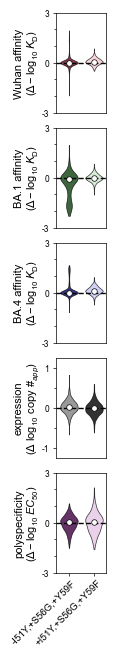

In [22]:
print("\n" + "="*70)
print("Effect of S31N on backgrounds with/without I51Y, S56G, Y59F")
print("="*70)

filtered_S31N = {}
for name in all_deltas:
    filtered_S31N[name] = all_deltas[name][all_deltas[name]['position'] == 1].copy()

data_S31N_1 = {}
for name in filtered_S31N:
    df = filtered_S31N[name]
    no_mut = df[df['source'].apply(lambda x: x[2]=='0' and x[3]=='0' and x[4]=='0')]
    with_mut = df[df['source'].apply(lambda x: x[2]=='1' and x[3]=='1' and x[4]=='1')]
    data_S31N_1[name] = [no_mut, with_mut]

create_violin_plot(data_S31N_1, 'S31N', 
                   ['-I51Y,+S56G,+Y59F', '+I51Y,+S56G,+Y59F'], 
                   'S_Figure_8b','S31N_analysis1')

## I51Y (index 2) and all combinations of other HCDR2 mutations (S56G and Y59F at indices 3 and 4)


Effect of I51Y on backgrounds with different S56G, Y59F combinations
Saved PNG: mutation_background_plots/S_Figure_8a.png
Canvas size: 1.00 × 3.00 inches
Total figure size: 1.60 × 6.20 inches
At 2000 DPI: 3200 × 12399 pixels


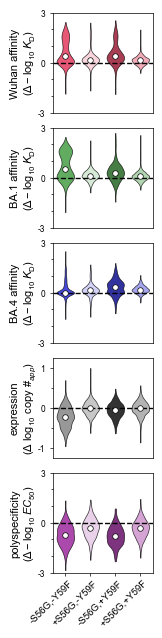

In [23]:
print("\n" + "="*70)
print("Effect of I51Y on backgrounds with different S56G, Y59F combinations")
print("="*70)

filtered_I51Y = {}
for name in all_deltas:
    filtered_I51Y[name] = all_deltas[name][all_deltas[name]['position'] == 2].copy()

data_I51Y = {}
for name in filtered_I51Y:
    df = filtered_I51Y[name]
    no_both = df[df['source'].apply(lambda x: x[3]=='0' and x[4]=='0')]
    with_S56G = df[df['source'].apply(lambda x: x[3]=='1' and x[4]=='0')]
    with_Y59F = df[df['source'].apply(lambda x: x[3]=='0' and x[4]=='1')]
    with_both = df[df['source'].apply(lambda x: x[3]=='1' and x[4]=='1')]
    data_I51Y[name] = [no_both, with_S56G, with_Y59F, with_both]

create_violin_plot(data_I51Y, 'I51Y',
                   ['-S56G,-Y59F', '+S56G,-Y59F', '-S56G,+Y59F', '+S56G,+Y59F'],
                   'S_Figure_8a','I51Y_analysis2')

## S94T (index 11) and HCDR2 mutations: all absent vs all present (I51Y, S56G, Y59F at indices 2, 3, 4)


Effect of S94T on backgrounds with/without I51Y, S56G, Y59F
Saved PNG: mutation_background_plots/S_Figure_8c.png
Canvas size: 0.50 × 3.00 inches
Total figure size: 1.10 × 6.20 inches
At 2000 DPI: 2200 × 12399 pixels


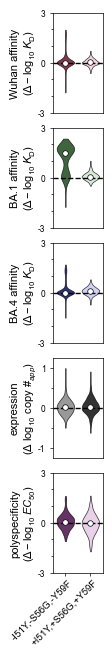


All analyses complete!
Output files saved to: mutation_background_plots/


In [24]:
print("\n" + "="*70)
print("Effect of S94T on backgrounds with/without I51Y, S56G, Y59F")
print("="*70)

filtered_S94T = {}
for name in all_deltas:
    filtered_S94T[name] = all_deltas[name][all_deltas[name]['position'] == 11].copy()

data_S94T = {}
for name in filtered_S94T:
    df = filtered_S94T[name]
    no_mut = df[df['source'].apply(lambda x: x[2]=='0' and x[3]=='0' and x[4]=='0')]
    with_mut = df[df['source'].apply(lambda x: x[2]=='1' and x[3]=='1' and x[4]=='1')]
    data_S94T[name] = [no_mut, with_mut]

create_violin_plot(data_S94T, 'S94T',
                   ['-I51Y,-S56G,-Y59F', '+I51Y,+S56G,+Y59F'],
                   'S_Figure_8c','S94T_analysis7')

print("\n" + "="*70)
print("All analyses complete!")
print(f"Output files saved to: {OUTPUT_DIR}/")
print("="*70)